# Global Spatial Organization in PDAC vs IgG4-AIP

This notebook is the whole-slide spatial-stats companion to the PDAC pseudotime notebooks.

Main goals:
1. Compare whole-slide spatial organization between `PDAC` and `IgG4AIP` with `Tier_A` phenotypes.
2. Refine the immune architecture with selected `Tier_B` subtypes.
3. Quantify epithelial-to-microenvironment spatial feature coupling with cross Moran's I.

Notes:
- `13737_1` (`pNET`) is excluded.
- `NormalPancreas` is kept as a qualitative reference, not a balanced disease group.
- The code processes one slide at a time and downsamples within phenotype to stay memory-safe.


In [1]:
from pathlib import Path
import gc
import importlib
import os
import sys
import types
import warnings

import anndata as ad
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from scipy import sparse

sns.set_context("talk")
sns.set_style("white")
pd.set_option("display.max_columns", 200)
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_ROOT = Path("/Volumes/Shihong_5/pancreatic_image_analysis/data/processed")
OUTPUT_DIR = Path("results/global_organization_pdac_igg4aip")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str((OUTPUT_DIR / "mplconfig").resolve()))
os.environ.setdefault("NUMBA_CACHE_DIR", str((OUTPUT_DIR / "numba_cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["NUMBA_CACHE_DIR"]).mkdir(parents=True, exist_ok=True)

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "spatioev" / "spatial" / "spatial_stats.py").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate repo root containing spatioev/spatial/spatial_stats.py"
    )


repo_root = find_repo_root(Path.cwd())
if "spatioev" not in sys.modules:
    spatioev_pkg = types.ModuleType("spatioev")
    spatioev_pkg.__path__ = [str(repo_root / "spatioev")]
    sys.modules["spatioev"] = spatioev_pkg
if "spatioev.spatial" not in sys.modules:
    spatial_pkg = types.ModuleType("spatioev.spatial")
    spatial_pkg.__path__ = [str(repo_root / "spatioev" / "spatial")]
    sys.modules["spatioev.spatial"] = spatial_pkg

spatial_stats = importlib.import_module("spatioev.spatial.spatial_stats")

SAMPLE_TYPES = {
    "8053_1": "IgG4AIP",
    "29624_1": "IgG4AIP",
    "33694_1": "PDAC",
    "34434_1": "PDAC",
    "35559_1": "PDAC",
    "40331_1": "NormalPancreas",
    "45041_1": "IgG4AIP",
}
EXCLUDED_SAMPLES = {"13737_1"}
DISEASE_ORDER = ["PDAC", "IgG4AIP", "NormalPancreas"]
DISEASE_PALETTE = {
    "PDAC": "#b2182b",
    "IgG4AIP": "#2166ac",
    "NormalPancreas": "#4d4d4d",
}

PIXEL_SIZE_UM = 0.325

FOCUSED_TIER_A = [
    "pancreatic ductal epithelium",
    "Fibroblasts",
    "T cells",
    "B lineage",
    "Endothelial cells",
    "Vimentin only mesenchyme",
    "pancreatic acinar epithelium",
]

TIER_A_PAIR_LIST = [
    ("pancreatic ductal epithelium", "Fibroblasts"),
    ("pancreatic ductal epithelium", "T cells"),
    ("pancreatic ductal epithelium", "B lineage"),
    ("Fibroblasts", "T cells"),
    ("Fibroblasts", "B lineage"),
    ("B lineage", "pancreatic ductal epithelium"),
]

TIER_A_SINGLE_RADII_UM = [30, 60]
TIER_A_CURVE_RADII_UM = np.arange(10, 121, 10)
TIER_A_CURVE_PAIRS = [
    ("pancreatic ductal epithelium", "Fibroblasts"),
    ("pancreatic ductal epithelium", "T cells"),
    ("pancreatic ductal epithelium", "B lineage"),
    ("Fibroblasts", "B lineage"),
]
TIER_A_ENVELOPE_PAIRS = [
    ("pancreatic ductal epithelium", "Fibroblasts"),
    ("pancreatic ductal epithelium", "T cells"),
    ("pancreatic ductal epithelium", "B lineage"),
]

MAX_CELLS_PER_TIER_A = 75_000
MAX_CELLS_PER_CURVE = 25_000
MAX_CELLS_PER_ENVELOPE = 15_000
ENVELOPE_N_SIM = 49

SELECTED_TIER_B = {
    "T_cell_subtypes": [
        "activated CD4 T cells",
        "CD4 T cells",
        "activated CD8 T cells",
        "CD8 T cells",
        "Tregs",
    ],
    "B_cell_subtypes": [
        "memory B cells",
        "plasmablasts-like",
    ],
    "Fibroblast_subtypes": [
        "aSMA+FAP-Thy1-PDPN- fibroblasts",
        "aSMA+FAP-Thy1+PDPN- fibroblasts",
        "aSMA-FAP-Thy1+PDPN- fibroblasts",
        "aSMA+FAP-Thy1+PDPN+ fibroblasts",
        "aSMA+FAP+Thy1+PDPN- fibroblasts",
    ],
}

TIER_B_PAIR_LIST = [
    ("activated CD8 T cells", "Tregs"),
    ("activated CD4 T cells", "Tregs"),
    ("memory B cells", "plasmablasts-like"),
    ("activated CD4 T cells", "memory B cells"),
    ("activated CD8 T cells", "memory B cells"),
]
TIER_B_SINGLE_RADII_UM = [30, 60]
TIER_B_CURVE_RADII_UM = np.arange(10, 121, 10)
TIER_B_CURVE_PAIRS = [
    ("memory B cells", "plasmablasts-like"),
    ("activated CD8 T cells", "Tregs"),
]
MAX_CELLS_PER_TIER_B = 50_000
MAX_CELLS_PER_TIER_B_CURVE = 20_000

SOURCE_PHENOTYPE = "pancreatic ductal epithelium"
SOURCE_OBS_FEATURE_CANDIDATES = [
    "area",
    "nc_ratio",
    "major_minor_axis_ratio",
    "convex_hull_resid",
    "centroid_dif",
    "num_concavities",
]
SOURCE_MARKER_CANDIDATES = ["CK19", "NaKATPase", "Ki67", "Vimentin"]
TARGET_COMPARTMENT_MARKERS = {
    "Fibroblasts": ["FAP", "aSMA", "PDPN", "Thy1", "Vimentin"],
    "T cells": ["CD3", "CD4", "CD8", "FOXP3", "GZMB", "Ki67"],
    "B lineage": ["CD19", "CD20", "CD27", "CD38", "IgA", "IgM", "PDL1"],
}
LOCAL_NEAR_DUCT_TARGET = "pancreatic ductal epithelium"
LOCAL_NEAR_DUCT_SOURCE_MARKERS = {
    "Fibroblasts": ["FAP", "aSMA", "PDPN", "Thy1", "Ki67", "Vimentin"],
    "T cells": ["CD3", "CD4", "CD8", "FOXP3", "GZMB", "Ki67"],
    "B lineage": ["CD19", "CD20", "CD27", "CD38", "IgA", "IgM", "PDL1"],
}
LOCAL_NEAR_DUCT_RADIUS_UM = 30
MAX_LOCAL_NEAR_DUCT_CELLS = 60_000
MAX_SOURCE_CELLS_CROSS_MORAN = 40_000
MAX_TARGET_CELLS_CROSS_MORAN = 80_000
CROSS_MORAN_RADIUS_UM = 30
CROSS_MORAN_N_SIM = 199
ALL_PAIRS_RADIUS_UM = 30
MAX_CELLS_ALL_PAIRS = 40_000

FONT_SIZES = {
    "title": 10,
    "axis_label": 9,
    "tick": 8,
    "legend": 7,
    "suptitle": 12,
    "annot": 7,
}

SHORT_LABELS = {
    "pancreatic ductal epithelium": "Ductal",
    "pancreatic acinar epithelium": "Acinar",
    "Vimentin only mesenchyme": "VIM+ mesench.",
    "Endothelial cells": "Endothelial",
    "Fibroblasts": "Fibroblasts",
    "T cells": "T cells",
    "B lineage": "B lineage",
    "memory B cells": "Memory B",
    "plasmablasts-like": "Plasmablast-like",
    "activated CD4 T cells": "Act CD4",
    "activated CD8 T cells": "Act CD8",
    "CD4 T cells": "CD4",
    "CD8 T cells": "CD8",
    "Tregs": "Tregs",
}


In [2]:
def build_slide_registry(data_root, sample_types, excluded_samples=None):
    excluded_samples = set(excluded_samples or [])
    rows = []
    for path in sorted(data_root.glob("*_adata_annotated.h5ad")):
        sample_id = path.name.replace("_adata_annotated.h5ad", "")
        if sample_id in excluded_samples:
            continue
        if sample_id not in sample_types:
            continue
        rows.append(
            {
                "sample_id": sample_id,
                "disease": sample_types[sample_id],
                "path": path,
            }
        )
    return pd.DataFrame(rows).sort_values(["disease", "sample_id"]).reset_index(drop=True)


slide_registry = build_slide_registry(DATA_ROOT, SAMPLE_TYPES, EXCLUDED_SAMPLES)
slide_registry


,sample_id,disease,path
0,29624_1,IgG4AIP,/Volumes/Shihong_5/pancreatic_image_analysis/d...
1,45041_1,IgG4AIP,/Volumes/Shihong_5/pancreatic_image_analysis/d...
2,8053_1,IgG4AIP,/Volumes/Shihong_5/pancreatic_image_analysis/d...
3,40331_1,NormalPancreas,/Volumes/Shihong_5/pancreatic_image_analysis/d...
4,33694_1,PDAC,/Volumes/Shihong_5/pancreatic_image_analysis/d...
5,34434_1,PDAC,/Volumes/Shihong_5/pancreatic_image_analysis/d...
6,35559_1,PDAC,/Volumes/Shihong_5/pancreatic_image_analysis/d...


In [3]:
def um_to_px(radius_um, pixel_size_um=PIXEL_SIZE_UM):
    return float(radius_um / pixel_size_um)


def px_to_um(radius_px, pixel_size_um=PIXEL_SIZE_UM):
    return float(radius_px * pixel_size_um)


def pair_label(source, target):
    src = SHORT_LABELS.get(source, source)
    tgt = SHORT_LABELS.get(target, target)
    return f"{src} → {tgt}"


def load_slide_obs(path, sample_id, disease, obs_cols, marker_names=None):
    adata = ad.read_h5ad(path, backed="r")

    obs_cols_present = [c for c in obs_cols if c in adata.obs.columns]
    obs_df = adata.obs[obs_cols_present].copy()
    obs_df["sample_id"] = sample_id
    obs_df["disease"] = disease

    present_markers = []
    for marker in list(marker_names or []):
        if marker in adata.var_names:
            present_markers.append(marker)

    if present_markers:
        X_markers = adata[:, present_markers].X
        if sparse.issparse(X_markers):
            X_markers = X_markers.toarray()
        X_markers = np.asarray(X_markers, dtype=np.float32)
        for idx, marker in enumerate(present_markers):
            obs_df[f"{marker}_expr"] = X_markers[:, idx]
            vals = pd.to_numeric(obs_df[f"{marker}_expr"], errors="coerce")
            mean = vals.mean(skipna=True)
            std = vals.std(skipna=True, ddof=0)
            if pd.notna(std) and std > 0:
                obs_df[f"{marker}_expr_z"] = (vals - mean) / std
            else:
                obs_df[f"{marker}_expr_z"] = np.nan
        del X_markers

    numeric_cols = set(
        [
            "X_centroid",
            "Y_centroid",
            "area",
            "nc_ratio",
            "major_minor_axis_ratio",
            "convex_hull_resid",
            "centroid_dif",
            "num_concavities",
            "orientation",
            "solidity",
            "feret_diameter_max",
            "circularity",
            "fractual_dimension",
            "boundary_irregularity",
            "polarity_score",
            "entropy",
            "inertia",
            "lacunarity",
            "elpigraph_pseudotime_pathology",
            "pdac_early_duct_anchor_score",
            "pdac_invasion_desmoplasia_axis",
            "pdac_dedifferentiation_axis",
        ]
    )
    numeric_cols.update([c for c in obs_df.columns if c.endswith("_expr") or c.endswith("_expr_z")])

    for col in [c for c in obs_df.columns if c in numeric_cols]:
        obs_df[col] = pd.to_numeric(obs_df[col], errors="coerce")

    for col in ["imageid", "Tier_A", "Tier_B", "spatial_count_radius_30_k15_merged", "sample_id", "disease"]:
        if col in obs_df.columns:
            obs_df[col] = obs_df[col].astype(str)

    if getattr(adata, "file", None) is not None:
        adata.file.close()
    del adata
    gc.collect()

    return obs_df


def sample_by_label(df, label_key, keep_labels=None, max_cells_per_label=50_000, random_state=0):
    out = df.copy()
    if keep_labels is not None:
        out = out[out[label_key].isin(keep_labels)].copy()

    parts = []
    for idx, (label, subset) in enumerate(out.groupby(label_key, observed=True)):
        if len(subset) > max_cells_per_label:
            subset = subset.sample(
                n=max_cells_per_label,
                random_state=random_state + idx,
            )
        parts.append(subset)

    if len(parts) == 0:
        return out.iloc[0:0].copy()

    return pd.concat(parts, axis=0).reset_index(drop=True)


def sample_source_target(
    df,
    phenotype_key,
    source_phenotype,
    target_phenotype,
    max_source_cells=40_000,
    max_target_cells=80_000,
    random_state=0,
):
    source_df = df[df[phenotype_key] == source_phenotype].copy()
    target_df = df[df[phenotype_key] == target_phenotype].copy()

    if len(source_df) > max_source_cells:
        source_df = source_df.sample(n=max_source_cells, random_state=random_state)
    if len(target_df) > max_target_cells:
        target_df = target_df.sample(n=max_target_cells, random_state=random_state + 1)

    merged = pd.concat([source_df, target_df], axis=0).drop_duplicates().reset_index(drop=True)
    return merged


def to_mini_adata(df):
    obs = df.copy()
    obs.index = obs.index.astype(str)
    return ad.AnnData(obs=obs)


def summarize_inventory(slide_registry):
    rows = []
    for row in slide_registry.itertuples(index=False):
        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "Tier_A", "Tier_B", "spatial_count_radius_30_k15_merged", "X_centroid", "Y_centroid"],
        )
        rows.append(
            {
                "sample_id": row.sample_id,
                "disease": row.disease,
                "n_cells": len(obs_df),
                "n_tier_a": obs_df["Tier_A"].nunique(dropna=True),
                "n_tier_b": obs_df["Tier_B"].nunique(dropna=True),
                "n_neighborhoods": obs_df["spatial_count_radius_30_k15_merged"].nunique(dropna=True),
            }
        )
        del obs_df
        gc.collect()
    return pd.DataFrame(rows)


def build_count_table(slide_registry, label_key):
    rows = []
    for row in slide_registry.itertuples(index=False):
        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", label_key],
        )
        counts = obs_df[label_key].value_counts(dropna=False)
        total = counts.sum()
        for label, n_cells in counts.items():
            rows.append(
                {
                    "sample_id": row.sample_id,
                    "disease": row.disease,
                    "label_key": label_key,
                    "label": label,
                    "n_cells": int(n_cells),
                    "proportion": float(n_cells / total) if total > 0 else np.nan,
                }
            )
        del obs_df
        gc.collect()
    return pd.DataFrame(rows)


def save_df(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_pickle(path)


def load_df(path):
    return pd.read_pickle(path)


def style_axis_fonts(ax, title_size=None, label_size=None, tick_size=None):
    title_size = FONT_SIZES["title"] if title_size is None else title_size
    label_size = FONT_SIZES["axis_label"] if label_size is None else label_size
    tick_size = FONT_SIZES["tick"] if tick_size is None else tick_size
    ax.title.set_fontsize(title_size)
    ax.xaxis.label.set_fontsize(label_size)
    ax.yaxis.label.set_fontsize(label_size)
    ax.tick_params(axis="both", labelsize=tick_size)


def style_legend(legend, fontsize=None):
    if legend is None:
        return
    fontsize = FONT_SIZES["legend"] if fontsize is None else fontsize
    for txt in legend.get_texts():
        txt.set_fontsize(fontsize)


def run_pairwise_ripley_suite(
    slide_registry,
    phenotype_key,
    focus_labels,
    pair_list,
    single_radii_um,
    curve_pairs=None,
    curve_radii_um=None,
    envelope_pairs=None,
    include_diseases=None,
    max_cells_single=50_000,
    max_cells_curve=20_000,
    max_cells_envelope=15_000,
    n_sim_envelope=49,
    min_cells_required=200,
    random_state=42,
):
    curve_pairs = list(curve_pairs or [])
    envelope_pairs = list(envelope_pairs or [])

    focus_union = set(focus_labels)
    for source, target in list(pair_list) + list(curve_pairs) + list(envelope_pairs):
        focus_union.add(source)
        focus_union.add(target)

    ripley_rows = []
    cross_rows = []
    curve_rows = []
    envelope_rows = []
    sampled_rows = []

    for slide_idx, row in enumerate(slide_registry.itertuples(index=False)):
        if include_diseases is not None and row.disease not in include_diseases:
            continue

        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "X_centroid", "Y_centroid", phenotype_key],
        )
        obs_df = obs_df.dropna(subset=["X_centroid", "Y_centroid", phenotype_key]).copy()
        obs_df = obs_df[obs_df[phenotype_key].isin(focus_union)].copy()

        if obs_df.empty:
            continue

        sampled_df = sample_by_label(
            obs_df,
            label_key=phenotype_key,
            keep_labels=sorted(focus_union),
            max_cells_per_label=max_cells_single,
            random_state=random_state + slide_idx * 100,
        )

        if sampled_df.empty:
            continue

        sampled_counts = (
            sampled_df[phenotype_key]
            .value_counts()
            .rename_axis("label")
            .reset_index(name="n_sampled")
        )
        sampled_counts["sample_id"] = row.sample_id
        sampled_counts["disease"] = row.disease
        sampled_counts["phenotype_key"] = phenotype_key
        sampled_rows.append(sampled_counts)

        adata_single = to_mini_adata(sampled_df)

        for radius_um in single_radii_um:
            radius_px = um_to_px(radius_um)
            ripley_df = spatial_stats.ripleys_k_by_phenotype(
                adata_single,
                phenotype_key=phenotype_key,
                radius=radius_px,
                x_key="X_centroid",
                y_key="Y_centroid",
                image_key="imageid",
            )
            ripley_df["sample_id"] = row.sample_id
            ripley_df["disease"] = row.disease
            ripley_df["phenotype_key"] = phenotype_key
            ripley_df["radius_um"] = radius_um
            ripley_rows.append(ripley_df)

            for source, target in pair_list:
                source_n = int((sampled_df[phenotype_key] == source).sum())
                target_n = int((sampled_df[phenotype_key] == target).sum())
                if min(source_n, target_n) < min_cells_required:
                    continue

                pair_df = spatial_stats.cross_ripleys_k_by_phenotype(
                    adata_single,
                    phenotype_key=phenotype_key,
                    source_phenotype=source,
                    target_phenotype=target,
                    radius=radius_px,
                    x_key="X_centroid",
                    y_key="Y_centroid",
                    image_key="imageid",
                )
                pair_df["sample_id"] = row.sample_id
                pair_df["disease"] = row.disease
                pair_df["phenotype_key"] = phenotype_key
                pair_df["radius_um"] = radius_um
                pair_df["pair_label"] = pair_df.apply(lambda x: pair_label(x["source"], x["target"]), axis=1)
                cross_rows.append(pair_df)

        if len(curve_pairs) > 0:
            curve_df = sample_by_label(
                obs_df,
                label_key=phenotype_key,
                keep_labels=sorted(focus_union),
                max_cells_per_label=max_cells_curve,
                random_state=random_state + slide_idx * 1000,
            )
            adata_curve = to_mini_adata(curve_df)
            radii_px = [um_to_px(r) for r in curve_radii_um]

            for source, target in curve_pairs:
                source_n = int((curve_df[phenotype_key] == source).sum())
                target_n = int((curve_df[phenotype_key] == target).sum())
                if min(source_n, target_n) < min_cells_required:
                    continue

                curve = spatial_stats.cross_ripleys_curve_by_phenotype(
                    adata_curve,
                    phenotype_key=phenotype_key,
                    source_phenotype=source,
                    target_phenotype=target,
                    radii=radii_px,
                    x_key="X_centroid",
                    y_key="Y_centroid",
                    image_key="imageid",
                )
                if curve.empty:
                    continue
                curve["sample_id"] = row.sample_id
                curve["disease"] = row.disease
                curve["phenotype_key"] = phenotype_key
                curve["radius_um"] = curve["radius"].astype(float) * PIXEL_SIZE_UM
                curve["pair_label"] = pair_label(source, target)
                curve_rows.append(curve)

        if len(envelope_pairs) > 0:
            env_df = sample_by_label(
                obs_df,
                label_key=phenotype_key,
                keep_labels=sorted(focus_union),
                max_cells_per_label=max_cells_envelope,
                random_state=random_state + slide_idx * 10_000,
            )
            adata_env = to_mini_adata(env_df)
            radii_px = [um_to_px(r) for r in curve_radii_um]

            for source, target in envelope_pairs:
                source_n = int((env_df[phenotype_key] == source).sum())
                target_n = int((env_df[phenotype_key] == target).sum())
                if min(source_n, target_n) < min_cells_required:
                    continue

                envelope = spatial_stats.cross_ripley_permutation_envelope(
                    adata_env,
                    phenotype_key=phenotype_key,
                    source_phenotype=source,
                    target_phenotype=target,
                    radii=radii_px,
                    n_sim=n_sim_envelope,
                    x_key="X_centroid",
                    y_key="Y_centroid",
                    image_key="imageid",
                    random_state=random_state + slide_idx,
                )
                if envelope.empty:
                    continue
                envelope["sample_id"] = row.sample_id
                envelope["disease"] = row.disease
                envelope["phenotype_key"] = phenotype_key
                envelope["radius_um"] = envelope["radius"].astype(float) * PIXEL_SIZE_UM
                envelope["pair_label"] = pair_label(source, target)
                envelope_rows.append(envelope)

        del obs_df, sampled_df, adata_single
        gc.collect()

    ripley_df = pd.concat(ripley_rows, ignore_index=True) if ripley_rows else pd.DataFrame()
    cross_df = pd.concat(cross_rows, ignore_index=True) if cross_rows else pd.DataFrame()
    curve_df = pd.concat(curve_rows, ignore_index=True) if curve_rows else pd.DataFrame()
    envelope_df = pd.concat(envelope_rows, ignore_index=True) if envelope_rows else pd.DataFrame()
    sampled_df = pd.concat(sampled_rows, ignore_index=True) if sampled_rows else pd.DataFrame()

    scale_rows = []
    if not curve_df.empty:
        grouping = ["sample_id", "disease", "phenotype_key", "source", "target", "pair_label"]
        for keys, sub_df in curve_df.groupby(grouping, observed=True):
            interaction_scale = spatial_stats.ripley_interaction_scale(sub_df[["radius", "L_minus_r"]].copy())
            spatial_scales = spatial_stats.ripley_spatial_scales(sub_df[["radius", "L_minus_r"]].copy())
            sample_id, disease, phenotype_key_value, source, target, pair_name = keys
            scale_rows.append(
                {
                    "sample_id": sample_id,
                    "disease": disease,
                    "phenotype_key": phenotype_key_value,
                    "source": source,
                    "target": target,
                    "pair_label": pair_name,
                    **interaction_scale,
                    **spatial_scales,
                }
            )
    scale_df = pd.DataFrame(scale_rows)

    return {
        "sampled_counts": sampled_df,
        "ripley_by_phenotype": ripley_df,
        "cross_ripley": cross_df,
        "cross_ripley_curve": curve_df,
        "cross_ripley_envelope": envelope_df,
        "cross_ripley_scales": scale_df,
    }


def run_cross_ripley_all_pairs(
    slide_registry,
    phenotype_key,
    focus_labels,
    radius_um,
    include_diseases=None,
    max_cells_per_label=40_000,
    include_self_pairs=False,
    random_state=42,
):
    rows = []
    for slide_idx, row in enumerate(slide_registry.itertuples(index=False)):
        if include_diseases is not None and row.disease not in include_diseases:
            continue

        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "X_centroid", "Y_centroid", phenotype_key],
        )
        obs_df = obs_df.dropna(subset=["X_centroid", "Y_centroid", phenotype_key]).copy()
        obs_df = obs_df[obs_df[phenotype_key].isin(focus_labels)].copy()
        if obs_df.empty:
            continue

        sampled_df = sample_by_label(
            obs_df,
            label_key=phenotype_key,
            keep_labels=focus_labels,
            max_cells_per_label=max_cells_per_label,
            random_state=random_state + slide_idx,
        )
        if sampled_df.empty:
            continue

        adata_small = to_mini_adata(sampled_df)
        out_df = spatial_stats.cross_ripleys_k_all_pairs(
            adata_small,
            phenotype_key=phenotype_key,
            radius=um_to_px(radius_um),
            x_key="X_centroid",
            y_key="Y_centroid",
            image_key="imageid",
            include_self_pairs=include_self_pairs,
        )
        if out_df.empty:
            continue
        out_df["sample_id"] = row.sample_id
        out_df["disease"] = row.disease
        out_df["phenotype_key"] = phenotype_key
        out_df["radius_um"] = radius_um
        out_df["pair_label"] = out_df.apply(lambda x: pair_label(x["source"], x["target"]), axis=1)
        rows.append(out_df)

        del obs_df, sampled_df, adata_small
        gc.collect()

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def run_local_near_duct_marker_analysis(
    slide_registry,
    source_marker_map,
    target_phenotype="pancreatic ductal epithelium",
    phenotype_key="Tier_A",
    radius_um=30,
    include_diseases=("PDAC", "IgG4AIP"),
    max_cells_per_label=60_000,
    random_state=42,
):
    marker_pool = sorted(
        {
            marker
            for markers in source_marker_map.values()
            for marker in markers
        }
    )
    local_rows = []
    marker_rows = []

    for slide_idx, row in enumerate(slide_registry.itertuples(index=False)):
        if include_diseases is not None and row.disease not in include_diseases:
            continue

        source_labels = list(source_marker_map.keys())
        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "X_centroid", "Y_centroid", phenotype_key],
            marker_names=marker_pool,
        )
        obs_df = obs_df.dropna(subset=["X_centroid", "Y_centroid", phenotype_key]).copy()
        obs_df = obs_df[obs_df[phenotype_key].isin(source_labels + [target_phenotype])].copy()
        if obs_df.empty:
            continue

        sampled_df = sample_by_label(
            obs_df,
            label_key=phenotype_key,
            keep_labels=source_labels + [target_phenotype],
            max_cells_per_label=max_cells_per_label,
            random_state=random_state + slide_idx,
        )
        adata_small = to_mini_adata(sampled_df)

        for source_phenotype, markers in source_marker_map.items():
            if source_phenotype not in set(sampled_df[phenotype_key].unique()):
                continue
            if target_phenotype not in set(sampled_df[phenotype_key].unique()):
                continue

            local_df = spatial_stats.cross_ripley_local_counts(
                adata_small,
                phenotype_key=phenotype_key,
                source_phenotype=source_phenotype,
                target_phenotype=target_phenotype,
                radius=um_to_px(radius_um),
                x_key="X_centroid",
                y_key="Y_centroid",
                image_key="imageid",
                add_to_obs=False,
            )
            if local_df.empty:
                continue

            local_df["sample_id"] = row.sample_id
            local_df["disease"] = row.disease
            local_df["source_phenotype"] = source_phenotype
            local_df["target_phenotype"] = target_phenotype
            local_df["radius_um"] = radius_um
            local_df["is_near_target"] = local_df["target_neighbor_count"] > 0
            local_df["cell_id"] = local_df["cell_id"].astype(str)
            local_rows.append(local_df)

            source_expr_df = sampled_df[sampled_df[phenotype_key] == source_phenotype].copy()
            source_expr_df["cell_id"] = source_expr_df.index.astype(str)
            merged = source_expr_df.merge(
                local_df[["cell_id", "target_neighbor_count", "target_neighbor_excess", "target_neighbor_ratio", "is_near_target"]],
                on="cell_id",
                how="inner",
            )

            for marker in markers:
                expr_col = f"{marker}_expr_z"
                if expr_col not in merged.columns:
                    continue
                for near_flag, subset in merged.groupby("is_near_target", observed=True):
                    vals = pd.to_numeric(subset[expr_col], errors="coerce")
                    vals = vals[np.isfinite(vals)]
                    if len(vals) == 0:
                        continue
                    marker_rows.append(
                        {
                            "sample_id": row.sample_id,
                            "disease": row.disease,
                            "source_phenotype": source_phenotype,
                            "target_phenotype": target_phenotype,
                            "radius_um": radius_um,
                            "marker": marker,
                            "expr_col": expr_col,
                            "is_near_target": bool(near_flag),
                            "n_cells": int(len(vals)),
                            "mean_expr_z": float(np.mean(vals)),
                            "median_expr_z": float(np.median(vals)),
                        }
                    )

        del obs_df, sampled_df, adata_small
        gc.collect()

    local_counts_df = pd.concat(local_rows, ignore_index=True) if local_rows else pd.DataFrame()
    marker_summary_df = pd.DataFrame(marker_rows)
    return local_counts_df, marker_summary_df


def plot_ripley_dotplot(df, value_key, radius_um, title, ylabel, hue="disease"):
    subset = df[df["radius_um"] == radius_um].copy()
    subset["phenotype"] = subset["phenotype"].map(lambda x: SHORT_LABELS.get(x, x))
    plt.figure(figsize=(8, 4))
    sns.stripplot(
        data=subset,
        x="phenotype",
        y=value_key,
        hue=hue,
        dodge=True,
        palette=DISEASE_PALETTE,
        size=8,
    )
    plt.xticks(rotation=45, ha="right", fontsize=FONT_SIZES["tick"])
    plt.yticks(fontsize=FONT_SIZES["tick"])
    plt.title(title, fontsize=FONT_SIZES["title"])
    plt.ylabel(ylabel, fontsize=FONT_SIZES["axis_label"])
    plt.xlabel("", fontsize=FONT_SIZES["axis_label"])
    plt.grid(False)
    leg = plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    style_legend(leg)
    plt.tight_layout()
    plt.show()


def plot_cross_ripley_heatmap(df, value_key, radius_um, title, center=None, fmt=".2f"):
    subset = df[df["radius_um"] == radius_um].copy()
    summary = (
        subset.groupby(["pair_label", "disease"], observed=True)[value_key]
        .mean()
        .reset_index()
        .pivot(index="pair_label", columns="disease", values=value_key)
    )
    summary = summary.reindex(columns=[d for d in DISEASE_ORDER if d in summary.columns])
    plt.figure(figsize=(5.8, max(3.5, 0.45 * len(summary))))
    ax = sns.heatmap(summary, annot=False, fmt=fmt, cmap="RdBu_r", center=center)
    ax.set_title(title, fontsize=FONT_SIZES["title"])
    ax.set_xlabel("", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("", fontsize=FONT_SIZES["axis_label"])
    ax.tick_params(axis="both", labelsize=FONT_SIZES["tick"])
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=FONT_SIZES["tick"])
    plt.tight_layout()
    plt.show()


def plot_cross_ripley_pair_dots(df, pairs, value_key, radius_um, title, ylabel):
    pair_names = [pair_label(source, target) for source, target in pairs]
    subset = df[(df["radius_um"] == radius_um) & (df["pair_label"].isin(pair_names))].copy()
    plt.figure(figsize=(7, 4))
    sns.stripplot(
        data=subset,
        x="pair_label",
        y=value_key,
        hue="disease",
        dodge=True,
        palette=DISEASE_PALETTE,
        size=8,
    )
    plt.xticks(rotation=45, ha="right", fontsize=FONT_SIZES["tick"])
    plt.yticks(fontsize=FONT_SIZES["tick"])
    plt.title(title, fontsize=FONT_SIZES["title"])
    plt.ylabel(ylabel, fontsize=FONT_SIZES["axis_label"])
    plt.xlabel("", fontsize=FONT_SIZES["axis_label"])
    plt.grid(False)
    leg = plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    style_legend(leg)
    plt.tight_layout()
    plt.show()


def plot_curve_panels(curve_df, pair_list, value_key="L_minus_r", title_prefix="Cross-Ripley"):
    if curve_df.empty:
        print("No curves available to plot.")
        return

    n_cols = 2
    n_rows = int(np.ceil(len(pair_list) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 3.5 * n_rows), sharex=True, sharey=False)
    axes = np.array(axes).reshape(-1)

    for ax, (source, target) in zip(axes, pair_list):
        pair_name = pair_label(source, target)
        sub = curve_df[curve_df["pair_label"] == pair_name].copy()
        if sub.empty:
            ax.axis("off")
            continue

        for disease, disease_df in sub.groupby("disease", observed=True):
            for sample_id, slide_df in disease_df.groupby("sample_id", observed=True):
                ax.plot(
                    slide_df["radius_um"],
                    slide_df[value_key],
                    color=DISEASE_PALETTE.get(disease, "gray"),
                    alpha=0.25,
                    linewidth=1.0,
                )

            mean_curve = (
                disease_df.groupby("radius_um", observed=True)[value_key]
                .mean()
                .reset_index()
            )
            ax.plot(
                mean_curve["radius_um"],
                mean_curve[value_key],
                color=DISEASE_PALETTE.get(disease, "gray"),
                linewidth=2.4,
                label=disease,
            )

        ax.set_title(pair_name, fontsize=FONT_SIZES["title"])
        ax.set_xlabel("Radius (um)", fontsize=FONT_SIZES["axis_label"])
        ax.set_ylabel(value_key, fontsize=FONT_SIZES["axis_label"])
        ax.grid(False)
        style_axis_fonts(ax)
        leg = ax.legend(frameon=False, fontsize=FONT_SIZES["legend"], loc="best")
        style_legend(leg)

    for ax in axes[len(pair_list):]:
        ax.axis("off")

    fig.suptitle(title_prefix, y=1.02, fontsize=FONT_SIZES["suptitle"])
    plt.tight_layout()
    plt.show()


def plot_envelope_panels(envelope_df, pair_list, disease_filter=("PDAC", "IgG4AIP")):
    if envelope_df.empty:
        print("No envelope results available to plot.")
        return

    n_cols = 1
    n_rows = len(pair_list)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7, 3.2 * n_rows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for ax, (source, target) in zip(axes, pair_list):
        pair_name = pair_label(source, target)
        sub = envelope_df[
            (envelope_df["pair_label"] == pair_name)
            & (envelope_df["disease"].isin(disease_filter))
        ].copy()
        if sub.empty:
            ax.axis("off")
            continue

        for disease, disease_df in sub.groupby("disease", observed=True):
            mean_df = (
                disease_df.groupby("radius_um", observed=True)[["L_minus_r", "envelope_low", "envelope_high"]]
                .mean()
                .reset_index()
            )
            color = DISEASE_PALETTE.get(disease, "gray")
            ax.plot(mean_df["radius_um"], mean_df["L_minus_r"], color=color, linewidth=2.2, label=disease)
            ax.fill_between(
                mean_df["radius_um"],
                mean_df["envelope_low"],
                mean_df["envelope_high"],
                color=color,
                alpha=0.18,
            )

        ax.set_title(pair_name, fontsize=FONT_SIZES["title"])
        ax.set_ylabel("L(r) - r", fontsize=FONT_SIZES["axis_label"])
        ax.grid(False)
        style_axis_fonts(ax)
        leg = ax.legend(frameon=False, fontsize=FONT_SIZES["legend"], loc="best")
        style_legend(leg)

    axes[-1].set_xlabel("Radius (um)", fontsize=FONT_SIZES["axis_label"])
    plt.tight_layout()
    plt.show()


def plot_marker_near_vs_not_boxplots(marker_summary_df, source_phenotype, title_prefix=None):
    sub = marker_summary_df[marker_summary_df["source_phenotype"] == source_phenotype].copy()
    if sub.empty:
        print(f"No marker summary available for {source_phenotype}.")
        return

    sub["near_status"] = np.where(sub["is_near_target"], "Near duct", "Not near duct")
    markers = list(sub["marker"].dropna().unique())
    plt.figure(figsize=(max(6, 0.9 * len(markers)), 4))
    sns.stripplot(
        data=sub,
        x="marker",
        y="mean_expr_z",
        hue="near_status",
        dodge=True,
        size=6,
        palette={"Near duct": "#b2182b", "Not near duct": "#2166ac"},
    )
    plt.title(
        title_prefix or f"{source_phenotype}: marker expression near vs not near ductal epithelium",
        fontsize=FONT_SIZES["title"],
    )
    plt.xlabel("", fontsize=FONT_SIZES["axis_label"])
    plt.ylabel("Per-slide mean z-scored expression", fontsize=FONT_SIZES["axis_label"])
    plt.xticks(rotation=45, ha="right", fontsize=FONT_SIZES["tick"])
    plt.yticks(fontsize=FONT_SIZES["tick"])
    leg = plt.legend(frameon=False, loc="best")
    style_legend(leg)
    plt.grid(False)
    plt.tight_layout()
    plt.show()


def plot_all_pairs_heatmap(df, value_key="fraction_source_with_target_neighbor", disease="PDAC", radius_um=30, center=None):
    sub = df[(df["disease"] == disease) & (df["radius_um"] == radius_um)].copy()
    if sub.empty:
        print(f"No all-pairs results for {disease} at {radius_um} um.")
        return
    wide = (
        sub.groupby(["source", "target"], observed=True)[value_key]
        .mean()
        .reset_index()
        .assign(
            source=lambda d: d["source"].map(lambda x: SHORT_LABELS.get(x, x)),
            target=lambda d: d["target"].map(lambda x: SHORT_LABELS.get(x, x)),
        )
        .pivot(index="source", columns="target", values=value_key)
    )
    plt.figure(figsize=(6.5, 5.2))
    ax = sns.heatmap(wide, cmap="RdBu_r", center=center, annot=False)
    ax.set_title(f"{disease}: fraction of source cells with target neighbors at {radius_um} um", fontsize=FONT_SIZES["title"])
    ax.set_xlabel("", fontsize=FONT_SIZES["axis_label"])
    ax.set_ylabel("", fontsize=FONT_SIZES["axis_label"])
    ax.tick_params(axis="both", labelsize=FONT_SIZES["tick"])
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=FONT_SIZES["tick"])
    plt.tight_layout()
    plt.show()


def run_cross_moran_feature_matrices(
    slide_registry,
    source_phenotype,
    target_compartment_markers,
    include_diseases=("PDAC", "IgG4AIP"),
    phenotype_key="Tier_A",
    source_obs_features=None,
    source_marker_candidates=None,
    radius_um=30,
    max_source_cells=40_000,
    max_target_cells=80_000,
    random_state=42,
):
    source_obs_features = list(source_obs_features or [])
    source_marker_candidates = list(source_marker_candidates or [])
    all_target_markers = sorted(
        {
            marker
            for markers in target_compartment_markers.values()
            for marker in markers
        }
    )
    all_markers = sorted(set(source_marker_candidates) | set(all_target_markers))

    rows = []
    availability_rows = []

    for slide_idx, row in enumerate(slide_registry.itertuples(index=False)):
        if include_diseases is not None and row.disease not in include_diseases:
            continue

        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "X_centroid", "Y_centroid", phenotype_key] + list(source_obs_features),
            marker_names=all_markers,
        )
        obs_df = obs_df.dropna(subset=["X_centroid", "Y_centroid", phenotype_key]).copy()
        if source_phenotype not in set(obs_df[phenotype_key].unique()):
            continue

        available_source_features = [f for f in source_obs_features if f in obs_df.columns]
        available_source_features.extend(
            [f"{m}_expr_z" for m in source_marker_candidates if f"{m}_expr_z" in obs_df.columns]
        )
        available_source_features = list(dict.fromkeys(available_source_features))

        for target_phenotype, target_markers in target_compartment_markers.items():
            if target_phenotype not in set(obs_df[phenotype_key].unique()):
                continue

            target_features = [f"{m}_expr_z" for m in target_markers if f"{m}_expr_z" in obs_df.columns]
            target_features = list(dict.fromkeys(target_features))

            availability_rows.append(
                {
                    "sample_id": row.sample_id,
                    "disease": row.disease,
                    "target_phenotype": target_phenotype,
                    "n_source_features": len(available_source_features),
                    "n_target_features": len(target_features),
                    "source_features": ", ".join(available_source_features),
                    "target_features": ", ".join(target_features),
                }
            )

            if len(available_source_features) == 0 or len(target_features) == 0:
                continue

            pair_df = sample_source_target(
                obs_df,
                phenotype_key=phenotype_key,
                source_phenotype=source_phenotype,
                target_phenotype=target_phenotype,
                max_source_cells=max_source_cells,
                max_target_cells=max_target_cells,
                random_state=random_state + slide_idx,
            )
            if pair_df.empty:
                continue

            adata_pair = to_mini_adata(pair_df)
            out_df = spatial_stats.cross_morans_i_feature_matrix(
                adata_pair,
                phenotype_key=phenotype_key,
                source_phenotype=source_phenotype,
                target_phenotype=target_phenotype,
                source_feature_keys=available_source_features,
                target_feature_keys=target_features,
                radius=um_to_px(radius_um),
                agg="mean",
                x_key="X_centroid",
                y_key="Y_centroid",
                image_key="imageid",
                k=8,
            )
            if out_df.empty:
                continue
            out_df["sample_id"] = row.sample_id
            out_df["disease"] = row.disease
            out_df["target_phenotype"] = target_phenotype
            out_df["radius_um"] = radius_um
            rows.append(out_df)

            del pair_df, adata_pair
            gc.collect()

        del obs_df
        gc.collect()

    results_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    availability_df = pd.DataFrame(availability_rows)
    return results_df, availability_df


def run_shortlist_cross_moran_permutations(
    slide_registry,
    shortlist,
    phenotype_key="Tier_A",
    source_phenotype="pancreatic ductal epithelium",
    radius_um=30,
    include_diseases=("PDAC", "IgG4AIP"),
    max_source_cells=30_000,
    max_target_cells=60_000,
    n_sim=199,
    random_state=42,
):
    all_markers = sorted(
        {
            marker
            for item in shortlist
            for marker in [item["source_marker"], item["target_marker"]]
            if marker is not None
        }
    )

    rows = []
    for slide_idx, row in enumerate(slide_registry.itertuples(index=False)):
        if include_diseases is not None and row.disease not in include_diseases:
            continue

        obs_df = load_slide_obs(
            row.path,
            row.sample_id,
            row.disease,
            obs_cols=["imageid", "X_centroid", "Y_centroid", phenotype_key] + SOURCE_OBS_FEATURE_CANDIDATES,
            marker_names=all_markers,
        )
        obs_df = obs_df.dropna(subset=["X_centroid", "Y_centroid", phenotype_key]).copy()

        for item in shortlist:
            target_phenotype = item["target_phenotype"]
            source_feature = item["source_feature"]
            target_marker = item["target_marker"]
            target_feature = f"{target_marker}_expr_z"

            if source_phenotype not in set(obs_df[phenotype_key].unique()):
                continue
            if target_phenotype not in set(obs_df[phenotype_key].unique()):
                continue
            if source_feature not in obs_df.columns or target_feature not in obs_df.columns:
                continue

            pair_df = sample_source_target(
                obs_df,
                phenotype_key=phenotype_key,
                source_phenotype=source_phenotype,
                target_phenotype=target_phenotype,
                max_source_cells=max_source_cells,
                max_target_cells=max_target_cells,
                random_state=random_state + slide_idx,
            )
            if pair_df.empty:
                continue

            adata_pair = to_mini_adata(pair_df)
            neighbor_df = spatial_stats.summarize_target_features_around_source_cells(
                adata_pair,
                phenotype_key=phenotype_key,
                source_phenotype=source_phenotype,
                target_phenotype=target_phenotype,
                target_feature_keys=[target_feature],
                radius=um_to_px(radius_um),
                agg="mean",
                x_key="X_centroid",
                y_key="Y_centroid",
                image_key="imageid",
                source_only=True,
            )
            if neighbor_df.empty:
                continue

            source_df = adata_pair.obs[adata_pair.obs[phenotype_key] == source_phenotype].copy()
            source_df["cell_id"] = source_df.index.astype(str)
            neighbor_df["cell_id"] = neighbor_df["cell_id"].astype(str)

            merged = source_df.merge(
                neighbor_df[["cell_id", f"neighbor_mean__{target_feature}"]],
                on="cell_id",
                how="left",
            )
            stats = spatial_stats.cross_morans_i_permutation_test(
                coords=merged[["X_centroid", "Y_centroid"]].to_numpy(),
                x_values=merged[source_feature].to_numpy(),
                y_values=merged[f"neighbor_mean__{target_feature}"].to_numpy(),
                k=8,
                n_sim=n_sim,
                permute="y",
                random_state=random_state + slide_idx,
            )
            rows.append(
                {
                    "sample_id": row.sample_id,
                    "disease": row.disease,
                    "source_phenotype": source_phenotype,
                    "target_phenotype": target_phenotype,
                    "source_feature": source_feature,
                    "target_feature": target_feature,
                    **stats,
                }
            )

            del pair_df, adata_pair, neighbor_df, source_df, merged
            gc.collect()

        del obs_df
        gc.collect()

    return pd.DataFrame(rows)


def plot_feature_matrix_heatmaps(feature_matrix_df, target_phenotypes=None, value_key="cross_morans_i"):
    if feature_matrix_df.empty:
        print("No feature-matrix results available.")
        return

    if target_phenotypes is None:
        target_phenotypes = list(feature_matrix_df["target_phenotype"].dropna().unique())

    def clean_feature_label(name):
        name = str(name)
        name = name.replace("_expr_z", "")
        name = name.replace("_expr", "")
        name = name.replace("_z", "")
        return name

    for target_phenotype in target_phenotypes:
        sub = feature_matrix_df[feature_matrix_df["target_phenotype"] == target_phenotype].copy()
        if sub.empty:
            continue

        summary = (
            sub.groupby(["source_feature", "target_feature", "disease"], observed=True)[value_key]
            .mean()
            .reset_index()
        )

        for disease in [d for d in DISEASE_ORDER if d in set(summary["disease"].unique())]:
            disease_df = summary[summary["disease"] == disease]
            if disease_df.empty:
                continue
            wide = disease_df.pivot(index="source_feature", columns="target_feature", values=value_key)
            wide.index = [clean_feature_label(x) for x in wide.index]
            wide.columns = [clean_feature_label(x) for x in wide.columns]
            plt.figure(figsize=(1.1 * max(4, wide.shape[1]), 0.55 * max(4, wide.shape[0])))
            ax = sns.heatmap(wide, cmap="RdBu_r", center=0, annot=False)
            ax.set_title(f"{target_phenotype}: epithelial ↔ {target_phenotype} coupling ({disease})", fontsize=FONT_SIZES["title"])
            ax.set_xlabel("Target feature", fontsize=FONT_SIZES["axis_label"])
            ax.set_ylabel("Source feature", fontsize=FONT_SIZES["axis_label"])
            ax.tick_params(axis="both", labelsize=FONT_SIZES["tick"])
            cbar = ax.collections[0].colorbar
            cbar.ax.tick_params(labelsize=FONT_SIZES["tick"])
            plt.tight_layout()
            plt.show()


## Cohort Inventory

This section checks:
- slide sizes
- phenotype availability
- neighborhood availability

It also gives slide-level context for later plots, which is important because the unit of inference is the slide, not the individual cell.


In [4]:
inventory_df = summarize_inventory(slide_registry)
inventory_df.to_csv(OUTPUT_DIR / "slide_inventory.csv", index=False)
inventory_df


,sample_id,disease,n_cells,n_tier_a,n_tier_b,n_neighborhoods
0,29624_1,IgG4AIP,762228,12,40,10
1,45041_1,IgG4AIP,1024488,13,40,11
2,8053_1,IgG4AIP,1753416,14,42,10
3,40331_1,NormalPancreas,161810,10,30,7
4,33694_1,PDAC,2948627,18,46,13
5,34434_1,PDAC,1766481,16,44,12
6,35559_1,PDAC,2004486,14,41,10


In [5]:
tier_a_counts_df = build_count_table(slide_registry, "Tier_A")
tier_b_counts_df = build_count_table(slide_registry, "Tier_B")
neighborhood_counts_df = build_count_table(slide_registry, "spatial_count_radius_30_k15_merged")

save_df(tier_a_counts_df, OUTPUT_DIR / "tier_a_counts_by_slide.pkl")
save_df(tier_b_counts_df, OUTPUT_DIR / "tier_b_counts_by_slide.pkl")
save_df(neighborhood_counts_df, OUTPUT_DIR / "neighborhood_counts_by_slide.pkl")

display(
    tier_a_counts_df.groupby("label", observed=True)["n_cells"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
    .rename("n_cells")
    .reset_index()
)

display(
    tier_b_counts_df.groupby("label", observed=True)["n_cells"]
    .sum()
    .sort_values(ascending=False)
    .head(25)
    .rename("n_cells")
    .reset_index()
)

display(
    neighborhood_counts_df.groupby("label", observed=True)["n_cells"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .rename("n_cells")
    .reset_index()
)


,label,n_cells
0,Fibroblasts,3067278
1,pancreatic ductal epithelium,1588545
2,T cells,1382767
3,Vimentin only mesenchyme,1017896
4,Endothelial cells,778412
5,B lineage,636600
6,noise,436920
7,pancreatic acinar epithelium,414739
8,Duodenum epithelial,205751
9,Vascular smooth muscle,183278


,label,n_cells
0,pancreatic ductal epithelium,1588545
1,Vimentin only mesenchyme,1017896
2,Endothelial cells,778412
3,activated CD4 T cells,641896
4,aSMA+FAP-Thy1-PDPN- fibroblasts,589313
5,noise,436920
6,aSMA+FAP-Thy1+PDPN- fibroblasts,434314
7,pancreatic acinar epithelium,414739
8,aSMA-FAP-Thy1+PDPN- fibroblasts,399920
9,memory B cells,318251


,label,n_cells
0,RCN1 Fibroblast-rich,3312762
1,RCN3 Ductal epithelial-rich,1584461
2,RCN2 VIM+ mesenchymal-rich,1261230
3,RCN5 T-cell-rich,1074877
4,RCN7 Ductal/acinar epithelial-rich,654947
5,RCN12 Endothelial-rich,574610
6,RCN4 B-cell-rich,408230
7,RCN0 Noise-rich,402901
8,RCN9 Islet-rich,381520
9,RCN8 Duodenal epithelial-rich,275626


## Question 1. Are the same major cell types spatially organized differently in PDAC vs IgG4-AIP?

Main outputs:
- Ripley's K by phenotype (self-clustering)
- Source-centered cross-Ripley interaction summaries
- Cross-Ripley curves and characteristic scales
- Permutation envelopes for a small number of key phenotype pairs


In [6]:
tier_a_result_paths = {
    "sampled_counts": OUTPUT_DIR / "tier_a_sampled_counts.pkl",
    "ripley_by_phenotype": OUTPUT_DIR / "tier_a_ripley_by_phenotype.pkl",
    "cross_ripley": OUTPUT_DIR / "tier_a_cross_ripley.pkl",
    "cross_ripley_curve": OUTPUT_DIR / "tier_a_cross_ripley_curve.pkl",
    "cross_ripley_envelope": OUTPUT_DIR / "tier_a_cross_ripley_envelope.pkl",
    "cross_ripley_scales": OUTPUT_DIR / "tier_a_cross_ripley_scales.pkl",
}

FORCE_RERUN_TIER_A = False

if FORCE_RERUN_TIER_A or not all(path.exists() for path in tier_a_result_paths.values()):
    tier_a_results = run_pairwise_ripley_suite(
        slide_registry=slide_registry,
        phenotype_key="Tier_A",
        focus_labels=FOCUSED_TIER_A,
        pair_list=TIER_A_PAIR_LIST,
        single_radii_um=TIER_A_SINGLE_RADII_UM,
        curve_pairs=TIER_A_CURVE_PAIRS,
        curve_radii_um=TIER_A_CURVE_RADII_UM,
        envelope_pairs=TIER_A_ENVELOPE_PAIRS,
        include_diseases=None,
        max_cells_single=MAX_CELLS_PER_TIER_A,
        max_cells_curve=MAX_CELLS_PER_CURVE,
        max_cells_envelope=MAX_CELLS_PER_ENVELOPE,
        n_sim_envelope=ENVELOPE_N_SIM,
        min_cells_required=200,
        random_state=42,
    )
    for key, df in tier_a_results.items():
        save_df(df, tier_a_result_paths[key])
else:
    tier_a_results = {
        key: load_df(path)
        for key, path in tier_a_result_paths.items()
    }

tier_a_results["sampled_counts"].head()


,label,n_sampled,sample_id,disease,phenotype_key
0,Fibroblasts,75000,29624_1,IgG4AIP,Tier_A
1,Vimentin only mesenchyme,75000,29624_1,IgG4AIP,Tier_A
2,pancreatic ductal epithelium,70548,29624_1,IgG4AIP,Tier_A
3,pancreatic acinar epithelium,38360,29624_1,IgG4AIP,Tier_A
4,Endothelial cells,37271,29624_1,IgG4AIP,Tier_A


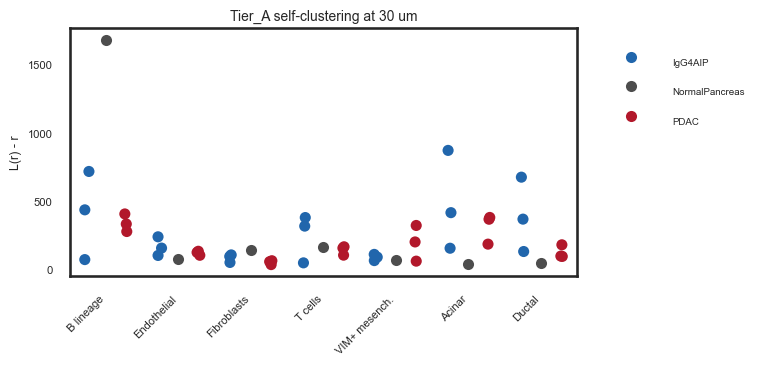

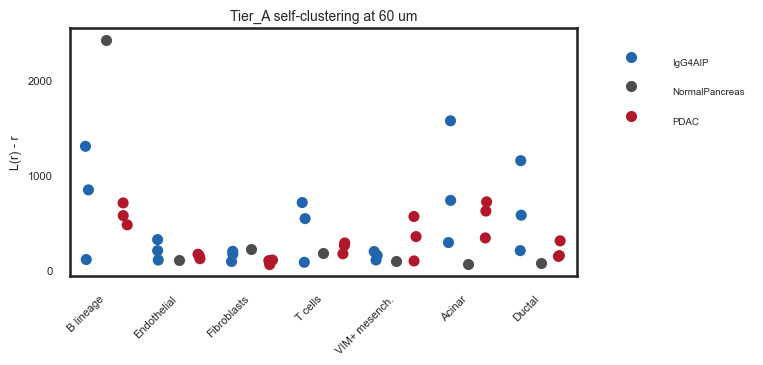

In [7]:
plot_ripley_dotplot(
    tier_a_results["ripley_by_phenotype"],
    value_key="L_minus_r",
    radius_um=30,
    title="Tier_A self-clustering at 30 um",
    ylabel="L(r) - r",
)

plot_ripley_dotplot(
    tier_a_results["ripley_by_phenotype"],
    value_key="L_minus_r",
    radius_um=60,
    title="Tier_A self-clustering at 60 um",
    ylabel="L(r) - r",
)


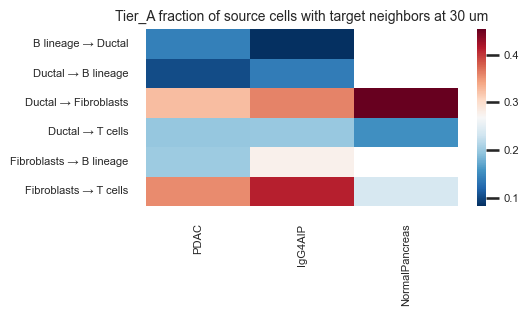

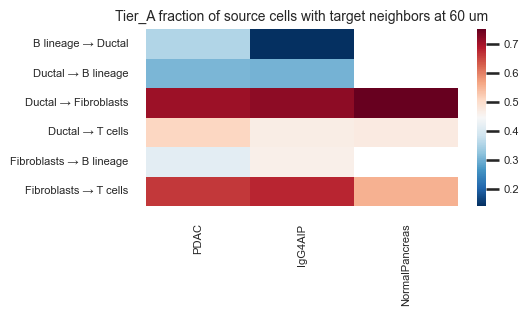

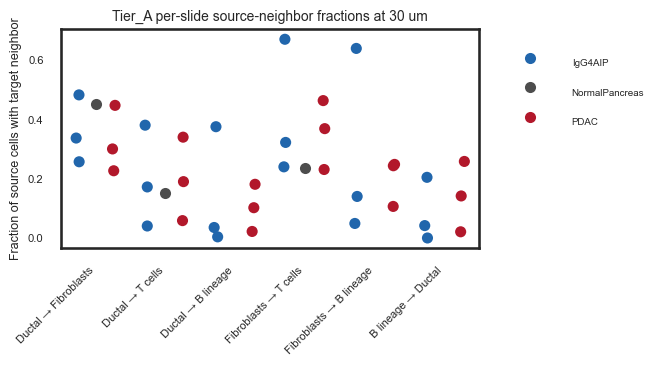

In [8]:
plot_cross_ripley_heatmap(
    tier_a_results["cross_ripley"],
    value_key="fraction_source_with_target_neighbor",
    radius_um=30,
    title="Tier_A fraction of source cells with target neighbors at 30 um",
    center=None,
)

plot_cross_ripley_heatmap(
    tier_a_results["cross_ripley"],
    value_key="fraction_source_with_target_neighbor",
    radius_um=60,
    title="Tier_A fraction of source cells with target neighbors at 60 um",
    center=None,
)

plot_cross_ripley_pair_dots(
    tier_a_results["cross_ripley"],
    pairs=TIER_A_PAIR_LIST,
    value_key="fraction_source_with_target_neighbor",
    radius_um=30,
    title="Tier_A per-slide source-neighbor fractions at 30 um",
    ylabel="Fraction of source cells with target neighbor",
)


## Question 2. At what spatial scale do the key PDAC and IgG4-AIP interactions happen?


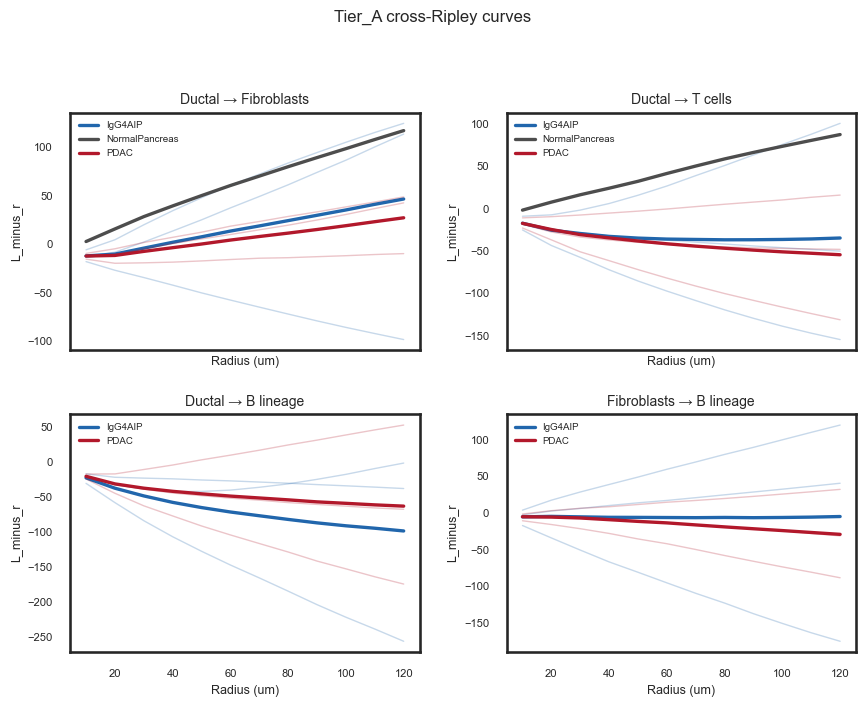

,sample_id,disease,phenotype_key,source,target,pair_label,interaction_radius,max_L_minus_r,interaction_strength,first_clustering_radius,peak_clustering_radius,peak_strength,repulsion_radius
0,29624_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,369.230769,-1.836710,-1.836710,NaN,369.230769,-1.836710,369.230769
1,45041_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,30.769231,-17.247273,-17.247273,NaN,30.769231,-17.247273,30.769231
2,8053_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,30.769231,-30.769231,-30.769231,NaN,30.769231,-30.769231,30.769231
3,33694_1,PDAC,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,30.769231,-24.579124,-24.579124,NaN,30.769231,-24.579124,30.769231
4,34434_1,PDAC,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,30.769231,-20.065325,-20.065325,NaN,30.769231,-20.065325,30.769231
5,35559_1,PDAC,Tier_A,pancreatic ductal epithelium,B lineage,Ductal → B lineage,369.230769,52.353177,52.353177,153.846154,369.230769,52.353177,NaN
6,29624_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,Fibroblasts,Ductal → Fibroblasts,369.230769,124.862204,124.862204,61.538462,369.230769,124.862204,NaN
7,45041_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,Fibroblasts,Ductal → Fibroblasts,30.769231,-18.046007,-18.046007,NaN,30.769231,-18.046007,30.769231
8,8053_1,IgG4AIP,Tier_A,pancreatic ductal epithelium,Fibroblasts,Ductal → Fibroblasts,369.230769,113.748767,113.748767,92.307692,369.230769,113.748767,NaN
9,40331_1,NormalPancreas,Tier_A,pancreatic ductal epithelium,Fibroblasts,Ductal → Fibroblasts,369.230769,117.350926,117.350926,30.769231,369.230769,117.350926,NaN


In [9]:
plot_curve_panels(
    tier_a_results["cross_ripley_curve"],
    pair_list=TIER_A_CURVE_PAIRS,
    value_key="L_minus_r",
    title_prefix="Tier_A cross-Ripley curves",
)

display(
    tier_a_results["cross_ripley_scales"]
    .sort_values(["pair_label", "disease", "sample_id"])
    .reset_index(drop=True)
)


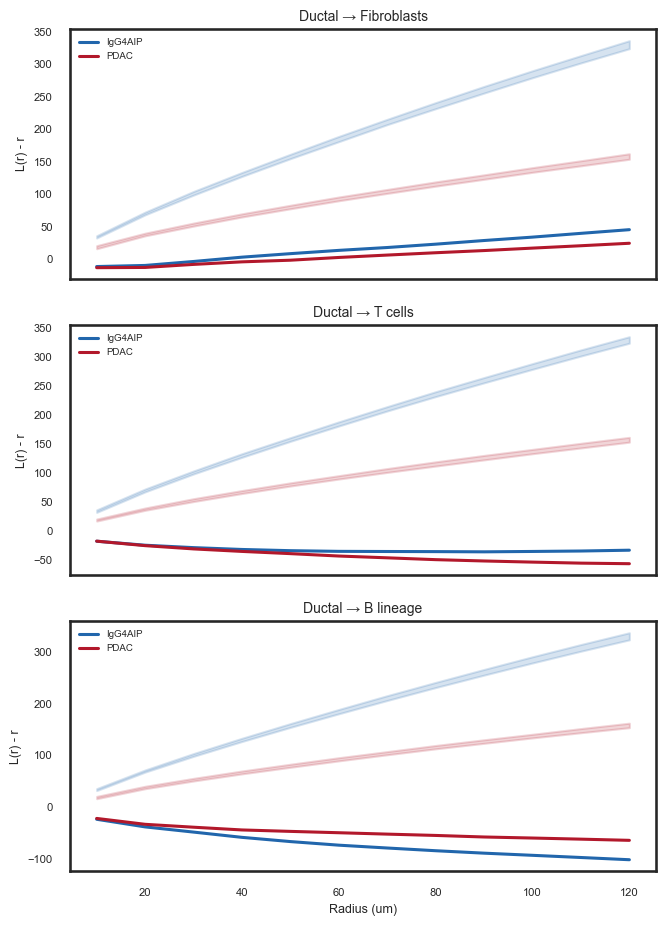

In [10]:
plot_envelope_panels(
    tier_a_results["cross_ripley_envelope"],
    pair_list=TIER_A_ENVELOPE_PAIRS,
    disease_filter=("PDAC", "IgG4AIP"),
)


### Optional overview: which phenotype pairs are broadly associated across the whole slide?

This is useful when you want one broader disease-level map of phenotype interaction architecture,
beyond the hand-picked pairs used in the main figures.


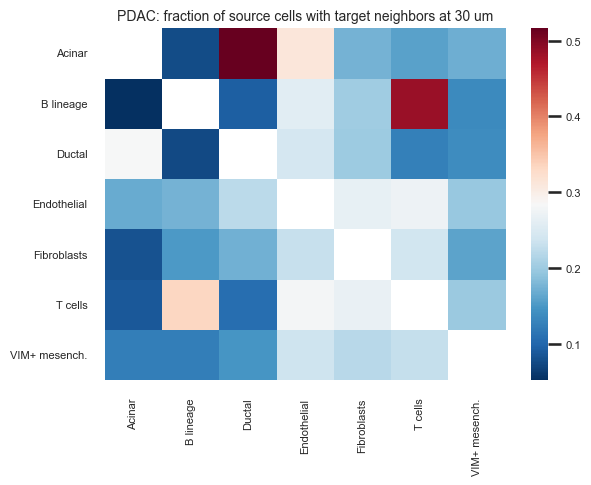

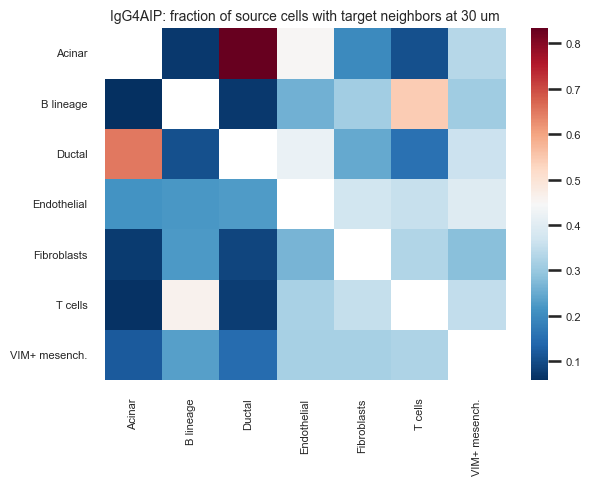

In [11]:
all_pairs_path = OUTPUT_DIR / "tier_a_cross_ripley_all_pairs.pkl"
FORCE_RERUN_ALL_PAIRS = False

if FORCE_RERUN_ALL_PAIRS or not all_pairs_path.exists():
    tier_a_all_pairs_df = run_cross_ripley_all_pairs(
        slide_registry=slide_registry,
        phenotype_key="Tier_A",
        focus_labels=FOCUSED_TIER_A,
        radius_um=ALL_PAIRS_RADIUS_UM,
        include_diseases=("PDAC", "IgG4AIP"),
        max_cells_per_label=MAX_CELLS_ALL_PAIRS,
        include_self_pairs=False,
        random_state=777,
    )
    save_df(tier_a_all_pairs_df, all_pairs_path)
else:
    tier_a_all_pairs_df = load_df(all_pairs_path)

plot_all_pairs_heatmap(
    tier_a_all_pairs_df,
    value_key="fraction_source_with_target_neighbor",
    disease="PDAC",
    radius_um=ALL_PAIRS_RADIUS_UM,
    center=None,
)

plot_all_pairs_heatmap(
    tier_a_all_pairs_df,
    value_key="fraction_source_with_target_neighbor",
    disease="IgG4AIP",
    radius_um=ALL_PAIRS_RADIUS_UM,
    center=None,
)


## Question 3. Do PDAC and IgG4-AIP differ in finer immune architecture beyond `Tier_A`?

This section keeps the subtype space intentionally small.

The goal is not to test every subtype combination. The goal is to show that `SpatioEv`
can distinguish different immune architectures inside broad `Tier_A` categories.


In [12]:
tier_b_focus_labels = sorted(
    {
        label
        for labels in SELECTED_TIER_B.values()
        for label in labels
    }
)

tier_b_present_summary = (
    tier_b_counts_df[tier_b_counts_df["label"].isin(tier_b_focus_labels)]
    .sort_values(["disease", "label", "sample_id"])
    .reset_index(drop=True)
)
tier_b_present_summary


,sample_id,disease,label_key,label,n_cells,proportion
0,29624_1,IgG4AIP,Tier_B,CD4 T cells,10266,0.013468
1,45041_1,IgG4AIP,Tier_B,CD4 T cells,138515,0.135204
2,8053_1,IgG4AIP,Tier_B,CD4 T cells,27624,0.015754
3,29624_1,IgG4AIP,Tier_B,CD8 T cells,5280,0.006927
4,45041_1,IgG4AIP,Tier_B,CD8 T cells,43701,0.042656
...,...,...,...,...,...,...
78,34434_1,PDAC,Tier_B,memory B cells,13299,0.007529
79,35559_1,PDAC,Tier_B,memory B cells,8099,0.004040
80,33694_1,PDAC,Tier_B,plasmablasts-like,59913,0.020319
81,34434_1,PDAC,Tier_B,plasmablasts-like,24237,0.013720


In [13]:
tier_b_result_paths = {
    "sampled_counts": OUTPUT_DIR / "tier_b_sampled_counts.pkl",
    "ripley_by_phenotype": OUTPUT_DIR / "tier_b_ripley_by_phenotype.pkl",
    "cross_ripley": OUTPUT_DIR / "tier_b_cross_ripley.pkl",
    "cross_ripley_curve": OUTPUT_DIR / "tier_b_cross_ripley_curve.pkl",
    "cross_ripley_envelope": OUTPUT_DIR / "tier_b_cross_ripley_envelope.pkl",
    "cross_ripley_scales": OUTPUT_DIR / "tier_b_cross_ripley_scales.pkl",
}

FORCE_RERUN_TIER_B = False

if FORCE_RERUN_TIER_B or not all(path.exists() for path in tier_b_result_paths.values()):
    tier_b_results = run_pairwise_ripley_suite(
        slide_registry=slide_registry,
        phenotype_key="Tier_B",
        focus_labels=tier_b_focus_labels,
        pair_list=TIER_B_PAIR_LIST,
        single_radii_um=TIER_B_SINGLE_RADII_UM,
        curve_pairs=TIER_B_CURVE_PAIRS,
        curve_radii_um=TIER_B_CURVE_RADII_UM,
        envelope_pairs=[],
        include_diseases=("PDAC", "IgG4AIP"),
        max_cells_single=MAX_CELLS_PER_TIER_B,
        max_cells_curve=MAX_CELLS_PER_TIER_B_CURVE,
        max_cells_envelope=MAX_CELLS_PER_TIER_B_CURVE,
        n_sim_envelope=0,
        min_cells_required=150,
        random_state=84,
    )
    for key, df in tier_b_results.items():
        save_df(df, tier_b_result_paths[key])
else:
    tier_b_results = {
        key: load_df(path)
        for key, path in tier_b_result_paths.items()
    }

tier_b_results["cross_ripley"].head()


,imageid,source,target,radius,K_observed,K_expected,L,L_minus_r,mean_target_neighbors_per_source,expected_target_neighbors_per_source,source_neighbor_excess,source_neighbor_ratio,fraction_source_with_target_neighbor,directional_observed,directional_expected,directional_excess,directional_ratio,sample_id,disease,phenotype_key,radius_um,pair_label
0,29624_1,activated CD8 T cells,Tregs,92.307692,2.395666e+05,26768.600125,276.145662,183.837970,0.139012,0.015533,0.123479,8.949539,0.099830,0.139012,0.015533,0.123479,8.949539,29624_1,IgG4AIP,Tier_B,30,Act CD8 → Tregs
1,29624_1,activated CD4 T cells,Tregs,92.307692,2.981119e+05,26768.600125,308.045417,215.737724,0.172984,0.015533,0.157451,11.136628,0.129441,0.172984,0.015533,0.157451,11.136628,29624_1,IgG4AIP,Tier_B,30,Act CD4 → Tregs
2,29624_1,memory B cells,plasmablasts-like,92.307692,2.943087e+04,26768.600125,96.789133,4.481440,0.061237,0.055698,0.005539,1.099455,0.046627,0.061237,0.055698,0.005539,1.099455,29624_1,IgG4AIP,Tier_B,30,Memory B → Plasmablast-like
3,29624_1,activated CD4 T cells,memory B cells,92.307692,1.406746e+06,26768.600125,669.164608,576.856915,1.620980,0.030845,1.590135,52.552108,0.269668,1.620980,0.030845,1.590135,52.552108,29624_1,IgG4AIP,Tier_B,30,Act CD4 → Memory B
4,29624_1,activated CD8 T cells,memory B cells,92.307692,8.104741e+05,26768.600125,507.919210,415.611517,0.933901,0.030845,0.903056,30.277045,0.186712,0.933901,0.030845,0.903056,30.277045,29624_1,IgG4AIP,Tier_B,30,Act CD8 → Memory B


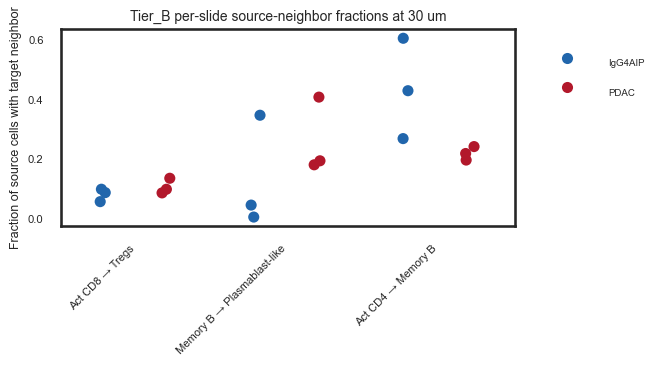

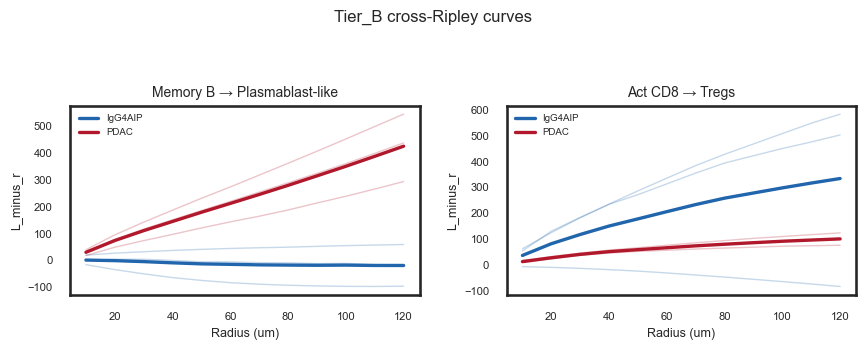

In [14]:
plot_cross_ripley_pair_dots(
    tier_b_results["cross_ripley"],
    pairs=[
        ("memory B cells", "plasmablasts-like"),
        ("activated CD8 T cells", "Tregs"),
        ("activated CD4 T cells", "memory B cells"),
    ],
    value_key="fraction_source_with_target_neighbor",
    radius_um=30,
    title="Tier_B per-slide source-neighbor fractions at 30 um",
    ylabel="Fraction of source cells with target neighbor",
)

plot_curve_panels(
    tier_b_results["cross_ripley_curve"],
    pair_list=TIER_B_CURVE_PAIRS,
    value_key="L_minus_r",
    title_prefix="Tier_B cross-Ripley curves",
)


## Question 4. Are epithelial states spatially coupled to stromal and immune states?

Here the source cells are `pancreatic ductal epithelium`, and the target compartments are:
- `Fibroblasts`
- `T cells`
- `B lineage`

This first-pass global notebook intentionally uses:
- a small set of robust source shape features already present in `adata.obs`
- epithelial marker features extracted directly from `adata.X`

That keeps the analysis portable across all slides without requiring the richer pixel-feature pipeline.


In [15]:
feature_matrix_path = OUTPUT_DIR / "epithelial_target_cross_moran_feature_matrix.pkl"
feature_availability_path = OUTPUT_DIR / "epithelial_target_feature_availability.csv"

FORCE_RERUN_FEATURE_MATRIX = False

if FORCE_RERUN_FEATURE_MATRIX or not feature_matrix_path.exists():
    feature_matrix_df, feature_availability_df = run_cross_moran_feature_matrices(
        slide_registry=slide_registry,
        source_phenotype=SOURCE_PHENOTYPE,
        target_compartment_markers=TARGET_COMPARTMENT_MARKERS,
        include_diseases=("PDAC", "IgG4AIP"),
        phenotype_key="Tier_A",
        source_obs_features=SOURCE_OBS_FEATURE_CANDIDATES,
        source_marker_candidates=SOURCE_MARKER_CANDIDATES,
        radius_um=CROSS_MORAN_RADIUS_UM,
        max_source_cells=MAX_SOURCE_CELLS_CROSS_MORAN,
        max_target_cells=MAX_TARGET_CELLS_CROSS_MORAN,
        random_state=123,
    )
    save_df(feature_matrix_df, feature_matrix_path)
    feature_availability_df.to_csv(feature_availability_path, index=False)
else:
    feature_matrix_df = load_df(feature_matrix_path)
    feature_availability_df = pd.read_csv(feature_availability_path)

display(feature_availability_df.head())
display(feature_matrix_df.head())


,sample_id,disease,target_phenotype,n_source_features,n_target_features,source_features,target_features
0,29624_1,IgG4AIP,Fibroblasts,10,5,"area, nc_ratio, major_minor_axis_ratio, convex...","FAP_expr, aSMA_expr, PDPN_expr, Thy1_expr, Vim..."
1,29624_1,IgG4AIP,T cells,10,6,"area, nc_ratio, major_minor_axis_ratio, convex...","CD3_expr, CD4_expr, CD8_expr, FOXP3_expr, GZMB..."
2,29624_1,IgG4AIP,B lineage,10,7,"area, nc_ratio, major_minor_axis_ratio, convex...","CD19_expr, CD20_expr, CD27_expr, CD38_expr, Ig..."
3,45041_1,IgG4AIP,Fibroblasts,10,5,"area, nc_ratio, major_minor_axis_ratio, convex...","FAP_expr, aSMA_expr, PDPN_expr, Thy1_expr, Vim..."
4,45041_1,IgG4AIP,T cells,10,6,"area, nc_ratio, major_minor_axis_ratio, convex...","CD3_expr, CD4_expr, CD8_expr, FOXP3_expr, GZMB..."


,imageid,source_phenotype,target_phenotype,source_feature,target_feature,target_summary_feature,cross_morans_i,n_source_cells,n_nonmissing_pairs,sample_id,disease,radius_um
0,29624_1,pancreatic ductal epithelium,Fibroblasts,area,FAP_expr,neighbor_mean__FAP_expr,0.065479,40000,19982,29624_1,IgG4AIP,30
1,29624_1,pancreatic ductal epithelium,Fibroblasts,area,aSMA_expr,neighbor_mean__aSMA_expr,0.016552,40000,19982,29624_1,IgG4AIP,30
2,29624_1,pancreatic ductal epithelium,Fibroblasts,area,PDPN_expr,neighbor_mean__PDPN_expr,-0.010175,40000,19982,29624_1,IgG4AIP,30
3,29624_1,pancreatic ductal epithelium,Fibroblasts,area,Thy1_expr,neighbor_mean__Thy1_expr,0.021631,40000,19982,29624_1,IgG4AIP,30
4,29624_1,pancreatic ductal epithelium,Fibroblasts,area,Vimentin_expr,neighbor_mean__Vimentin_expr,-0.002938,40000,19982,29624_1,IgG4AIP,30


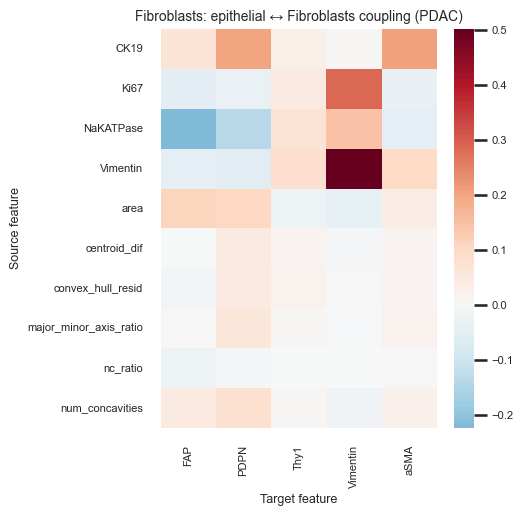

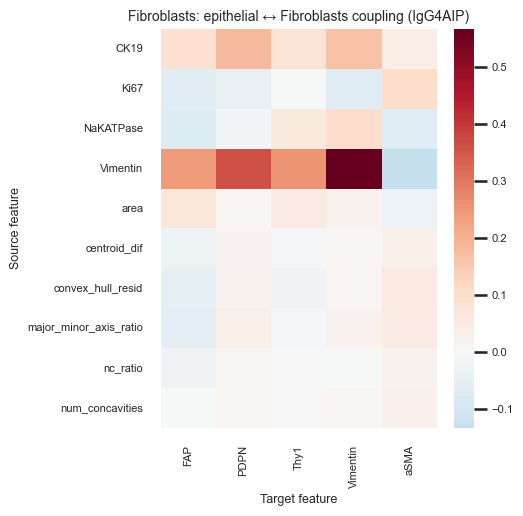

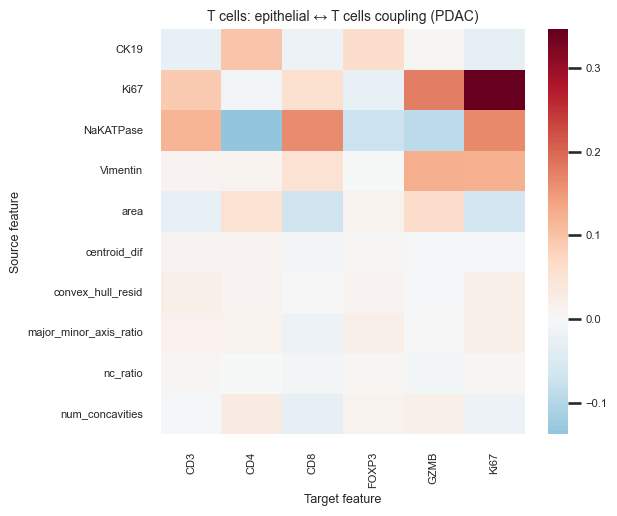

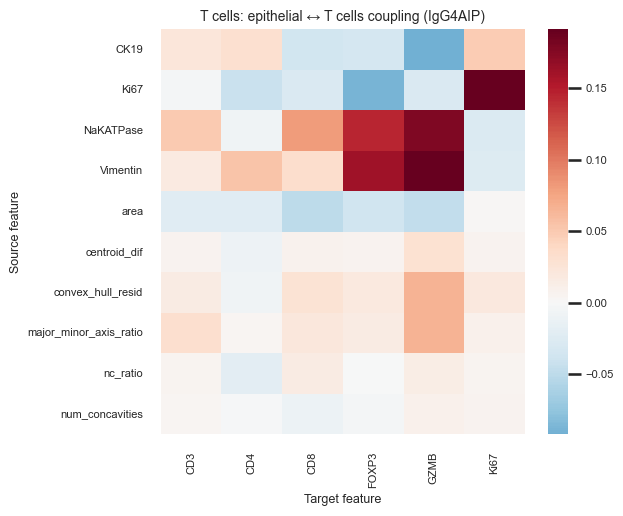

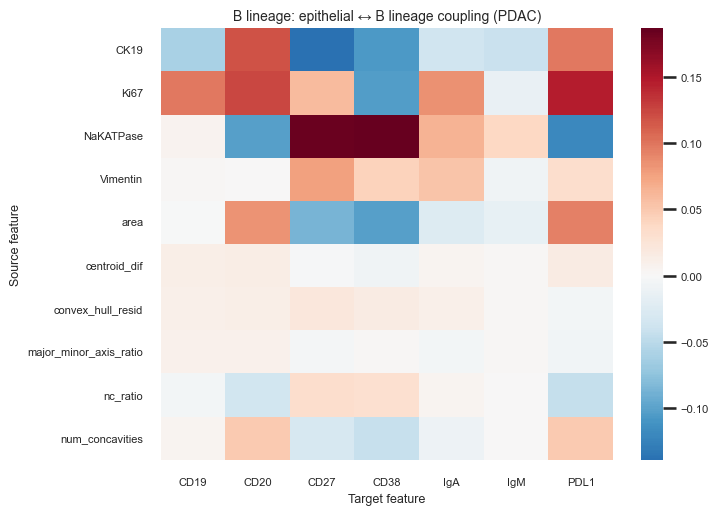

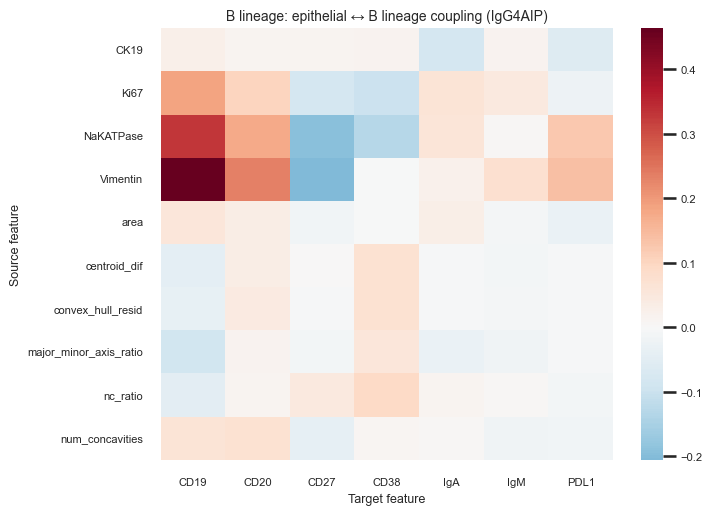

In [16]:
plot_feature_matrix_heatmaps(
    feature_matrix_df,
    target_phenotypes=["Fibroblasts", "T cells", "B lineage"],
    value_key="cross_morans_i",
)


In [17]:
shortlist_cross_moran_pairs = [
    {
        "target_phenotype": "Fibroblasts",
        "source_feature": "CK19_expr_z",
        "source_marker": "CK19",
        "target_marker": "FAP",
    },
    {
        "target_phenotype": "Fibroblasts",
        "source_feature": "Ki67_expr_z",
        "source_marker": "Ki67",
        "target_marker": "PDPN",
    },
    {
        "target_phenotype": "T cells",
        "source_feature": "NaKATPase_expr_z",
        "source_marker": "NaKATPase",
        "target_marker": "GZMB",
    },
    {
        "target_phenotype": "B lineage",
        "source_feature": "Ki67_expr_z",
        "source_marker": "Ki67",
        "target_marker": "CD38",
    },
]

if feature_matrix_df.empty:
    shortlist_cross_moran_pairs = []
else:
    available_source_features = set(feature_matrix_df["source_feature"].unique())
    available_target_features = set(feature_matrix_df["target_feature"].unique())
    available_target_phenotypes = set(feature_matrix_df["target_phenotype"].unique())
    shortlist_cross_moran_pairs = [
        item
        for item in shortlist_cross_moran_pairs
        if (
            (item["source_feature"] in available_source_features)
            and (f"{item['target_marker']}_expr_z" in available_target_features)
            and (item["target_phenotype"] in available_target_phenotypes)
        )
    ]

cross_moran_perm_path = OUTPUT_DIR / "cross_moran_shortlist_permutations.csv"
FORCE_RERUN_CROSS_MORAN_PERM = False

if len(shortlist_cross_moran_pairs) == 0:
    cross_moran_perm_df = pd.DataFrame()
    print("No shortlist pairs were available in the current data.")
elif FORCE_RERUN_CROSS_MORAN_PERM or not cross_moran_perm_path.exists():
    cross_moran_perm_df = run_shortlist_cross_moran_permutations(
        slide_registry=slide_registry,
        shortlist=shortlist_cross_moran_pairs,
        phenotype_key="Tier_A",
        source_phenotype=SOURCE_PHENOTYPE,
        radius_um=CROSS_MORAN_RADIUS_UM,
        include_diseases=("PDAC", "IgG4AIP"),
        max_source_cells=30_000,
        max_target_cells=60_000,
        n_sim=CROSS_MORAN_N_SIM,
        random_state=456,
    )
    cross_moran_perm_df.to_csv(cross_moran_perm_path, index=False)
else:
    cross_moran_perm_df = pd.read_csv(cross_moran_perm_path)

cross_moran_perm_df


No shortlist pairs were available in the current data.


""


## Question 5. Which fibroblasts or immune cells are near ducts, and do they differ in marker state?

This section asks a slightly different question from the global Ripley summaries:

- among `Fibroblasts`, which cells are near `pancreatic ductal epithelium`?
- among `T cells` or `B lineage`, which cells are near ducts?
- do those near-duct cells differ in marker expression from cells farther away?

This is a nice bridge figure between global tissue organization and microenvironmental state.


In [18]:
local_near_duct_counts_path = OUTPUT_DIR / "local_near_duct_counts.pkl"
local_near_duct_marker_path = OUTPUT_DIR / "local_near_duct_marker_summary.pkl"
FORCE_RERUN_LOCAL_NEAR_DUCT = False

if FORCE_RERUN_LOCAL_NEAR_DUCT or not (local_near_duct_counts_path.exists() and local_near_duct_marker_path.exists()):
    local_near_duct_df, local_near_duct_marker_df = run_local_near_duct_marker_analysis(
        slide_registry=slide_registry,
        source_marker_map=LOCAL_NEAR_DUCT_SOURCE_MARKERS,
        target_phenotype=LOCAL_NEAR_DUCT_TARGET,
        phenotype_key="Tier_A",
        radius_um=LOCAL_NEAR_DUCT_RADIUS_UM,
        include_diseases=("PDAC", "IgG4AIP"),
        max_cells_per_label=MAX_LOCAL_NEAR_DUCT_CELLS,
        random_state=999,
    )
    save_df(local_near_duct_df, local_near_duct_counts_path)
    save_df(local_near_duct_marker_df, local_near_duct_marker_path)
else:
    local_near_duct_df = load_df(local_near_duct_counts_path)
    local_near_duct_marker_df = load_df(local_near_duct_marker_path)

display(local_near_duct_df.head())
display(local_near_duct_marker_df.head())


,cell_id,imageid,source,target,radius,target_neighbor_count,expected_target_neighbor_count,target_neighbor_excess,target_neighbor_ratio,is_cross_ripley_hotspot,sample_id,disease,source_phenotype,target_phenotype,radius_um,is_near_target
0,14105,29624_1,Fibroblasts,pancreatic ductal epithelium,92.307692,0.0,0.575882,-0.575882,0.0,False,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,False
1,14106,29624_1,Fibroblasts,pancreatic ductal epithelium,92.307692,0.0,0.575882,-0.575882,0.0,False,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,False
2,14107,29624_1,Fibroblasts,pancreatic ductal epithelium,92.307692,0.0,0.575882,-0.575882,0.0,False,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,False
3,14108,29624_1,Fibroblasts,pancreatic ductal epithelium,92.307692,0.0,0.575882,-0.575882,0.0,False,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,False
4,14109,29624_1,Fibroblasts,pancreatic ductal epithelium,92.307692,0.0,0.575882,-0.575882,0.0,False,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,False


,sample_id,disease,source_phenotype,target_phenotype,radius_um,marker,expr_col,is_near_target,n_cells,mean_expr,median_expr
0,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,FAP,FAP_expr,False,52004,11.480279,11.615564
1,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,FAP,FAP_expr,True,7996,11.628281,11.675884
2,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,aSMA,aSMA_expr,False,52004,11.806067,11.797573
3,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,aSMA,aSMA_expr,True,7996,11.653072,11.663819
4,29624_1,IgG4AIP,Fibroblasts,pancreatic ductal epithelium,30,PDPN,PDPN_expr,False,52004,11.023551,11.373387


In [19]:
plot_marker_near_vs_not_boxplots(
    local_near_duct_marker_df,
    source_phenotype="Fibroblasts",
    title_prefix="Fibroblasts: marker expression near vs not near ductal epithelium",
)

plot_marker_near_vs_not_boxplots(
    local_near_duct_marker_df,
    source_phenotype="T cells",
    title_prefix="T cells: marker expression near vs not near ductal epithelium",
)

plot_marker_near_vs_not_boxplots(
    local_near_duct_marker_df,
    source_phenotype="B lineage",
    title_prefix="B lineage: marker expression near vs not near ductal epithelium",
)


ValueError: Could not interpret value `mean_expr_z` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

## Suggested Figure Set for the Seminar

If time is short, these are the highest-yield figures:

1. `Tier_A` self-clustering dotplot at `30 um`
2. `Tier_A` directional interaction heatmap at `30 um`
3. Cross-Ripley curves for:
   - `ductal → Fibroblasts`
   - `ductal → T cells`
   - `ductal → B lineage`
   - `Fibroblasts → B lineage`
4. `Tier_B` focused plot:
   - `memory B cells → plasmablasts-like`
   - `activated CD8 T cells → Tregs`
5. Local near-vs-not-near duct figure:
   - fibroblasts near vs not near ductal epithelium
6. Cross-Moran heatmap:
   - epithelial source features vs fibroblast features

That combination gives you:
- disease-level architecture
- immune refinement
- integrative epithelial–microenvironment coupling
